$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
\providecommand{\Xmat}{\mathbf{X}}
\providecommand{\Remp}{\mathcal{R}_{\text{emp}}}
$$

## Setup

You are given the following data situation:

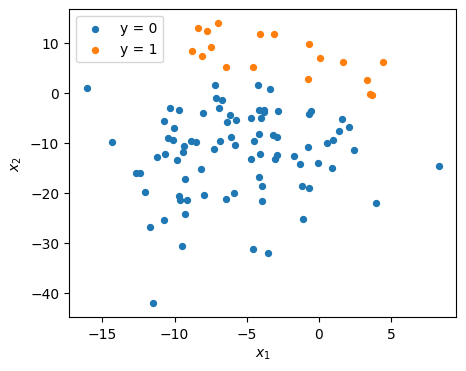

In [1]:
#| label: setup_data
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(314)
n = 100
X = np.column_stack([np.random.normal(-5, 5, n), np.random.normal(-10, 10, n)])
z = 2 * X[:, 0] + 3 * X[:, 1]
pr = 1 / (1 + np.exp(-z))
y = (pr > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
for label in (0, 1):
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=f"y = {label}", s=18)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.legend()
plt.show()

::: callout-note
**R vs. Python parity.** R's `set.seed(314)` and Python's `np.random.seed(314)` use *different* RNGs. The data above (and consequently the GD trajectories below) differ between languages. Both implementations are correct; only the underlying data differs. Compare *algorithmic behavior* (divergence, convergence, backtracking adaptation) rather than expecting numerically identical $\bm{\theta}$ values.
:::

In the following we want to estimate a logistic regression *without intercept* via gradient descent.

*Note: We use vanilla GD for educational purposes; in practice more sophisticated algorithms are typically preferred.*

## (a) Complete separation makes the empirical risk unbounded below

The data above is **completely separable**: the two classes can be perfectly classified with a linear classifier. Show that in this situation, if $\tilde{\bm{\theta}}$ perfectly classifies the data then

$$\mathcal{R}_\text{emp}(\tilde{\bm{\theta}}) > \mathcal{R}_\text{emp}(\alpha \tilde{\bm{\theta}}) \quad \text{for all } \alpha > 1.$$

*Implication:* the per-observation log-loss can be driven arbitrarily low by scaling $\bm{\theta}$, so the empirical risk has no finite minimum.

**Solution.**

We start with

$$\mathcal{R}_\text{emp}(\tilde{\bm{\theta}}) = \sum_{i=1}^n \log\!\left(1 + \exp(\tilde{\bm{\theta}}^\top \xv^{(i)})\right) - y^{(i)}\tilde{\bm{\theta}}^\top \xv^{(i)} = \sum_{i=1}^n \begin{cases} \log\!\left(1 + \exp(\tilde{\bm{\theta}}^\top \xv^{(i)})\right) & \text{if } y^{(i)} = 0, \\ \log\!\left(1 + \exp(\tilde{\bm{\theta}}^\top \xv^{(i)})\right) - \tilde{\bm{\theta}}^\top \xv^{(i)} & \text{if } y^{(i)} = 1. \end{cases}$$

Since $\tilde{\bm{\theta}}$ perfectly classifies the data, we know that

$$\begin{cases} \tilde{\bm{\theta}}^\top \xv^{(i)} < 0 & \text{if } y^{(i)} = 0, \\ \tilde{\bm{\theta}}^\top \xv^{(i)} \geq 0 & \text{if } y^{(i)} = 1. \end{cases}$$

Hence, we can focus on the functions $g(z) = \log(1 + \exp(-z))$ and $h(z) = \log(1 + \exp(z)) - z$ for $z > 0$ and study their monotonicity. (The $y = 1$ term is $h(z)$ with $z \geq 0$ directly; the $y = 0$ term $\log(1 + \exp(z))$ with $z < 0$ is $g(-z)$ with $-z > 0$. As functions $g$ and $h$ coincide — $\log(1+\exp(z)) - z = \log(1+\exp(-z))$ — so the two names just track which label case we are in.) We compute

$$g'(z) = -\underbrace{\frac{\exp(-z)}{1 + \exp(-z)}}_{> 0} < 0, \qquad h'(z) = \underbrace{\frac{\exp(z)}{1 + \exp(z)}}_{< 1} - 1 < 0.$$

Therefore, both $g$ and $h$ are strictly monotonically decreasing. It follows that $\mathcal{R}_\text{emp}(\tilde{\bm{\theta}}) > \mathcal{R}_\text{emp}(\alpha \tilde{\bm{\theta}})$ for $\alpha > 1$.

## (b) Visualize the empirical risk

Visualize $\mathcal{R}_\text{emp}$ on $[-1, 4] \times [-1, 4]$.

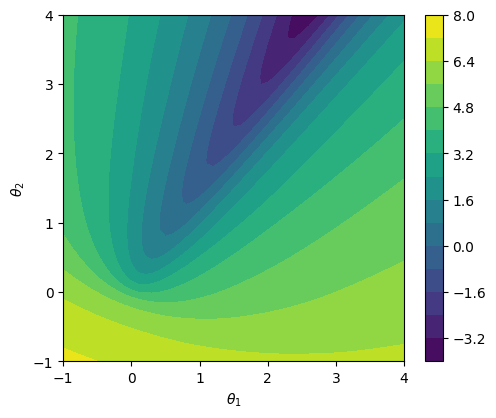

In [2]:
#| label: solution_b_code
def f(theta, lam):
    """L2-regularized logistic empirical risk (lam = 0 -> unregularized)."""
    theta = np.asarray(theta, dtype=float)
    z = X @ theta
    return float(lam * (theta @ theta) + np.sum(-y * z + np.log(1 + np.exp(z))))


grid = np.arange(-1, 4 + 0.1, 0.1)
T1, T2 = np.meshgrid(grid, grid)
# log-scale (as in (f)) to reveal the level-set shape across the wide range
Z = np.log(np.array([[f(np.array([t1, t2]), 0) for t1 in grid] for t2 in grid]))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cs = ax.contourf(T1, T2, Z, levels=14)
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")
fig.colorbar(cs)
plt.show()

The level sets of $\mathcal{R}_\text{emp}$ open toward the upper-right: the risk decreases without bound as $\bm{\theta}$ moves along that direction, consistent with (a).

## (c) Gradient of the empirical risk

Find $\nabla_{\bm{\theta}} \mathcal{R}_\text{emp}$ for arbitrary $\bm{\theta}$.

**Solution.**

Differentiating term-by-term:

$$\nabla_{\bm{\theta}} \mathcal{R}_\text{emp} = \sum_{i=1}^n \left(\sigma(\bm{\theta}^\top \xv^{(i)}) - y^{(i)}\right) \xv^{(i)}, \qquad \sigma(z) = \frac{1}{1 + e^{-z}}.$$

Equivalently in vector form: $\Xmat^\top (\sigma(\Xmat \bm{\theta}) - \yv)$ where $\sigma$ is applied element-wise. This is the standard logistic-regression gradient.

**Note on regularization.** When the L2-regularized objective is $\lambda\|\bm{\theta}\|^2 + \mathcal{R}_\text{emp}(\bm{\theta})$, the regularizer contributes an extra $2\lambda\bm{\theta}$ to the gradient — important for parts (e), (g).

## (d) Vanilla gradient descent

Solve the logistic regression via gradient descent. Use step size $\alpha = 0.01$, starting point $\bm{\theta}^{[0]} = (0, 0)^\top$, and train for $500$ steps. Repeat with $\alpha = 0.02$. Explain what you observe.

*Hint:* recall (a).

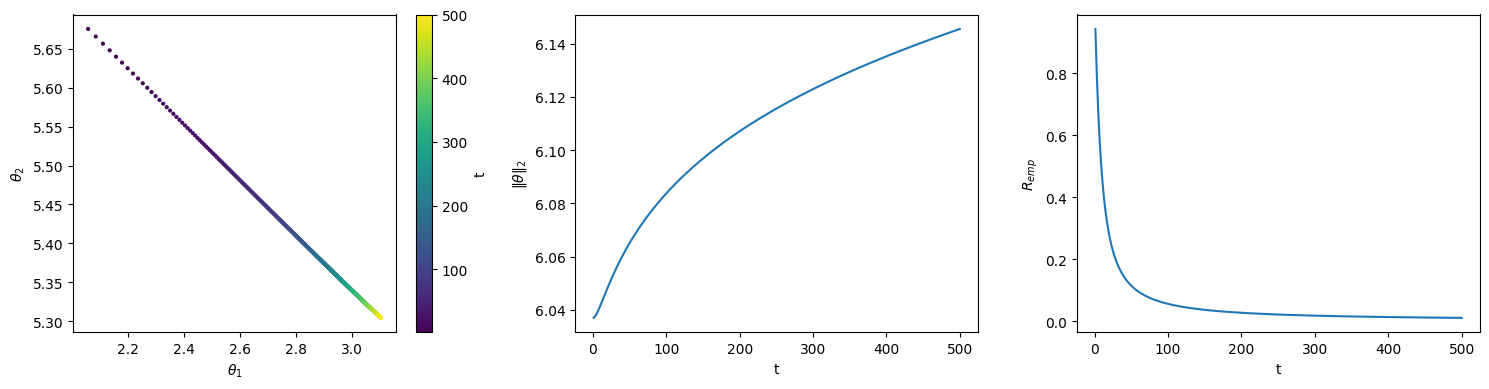

vanilla a=0.01         final theta = ( 3.1035,  5.3043), ||theta|| =   6.146, R_emp = 0.011


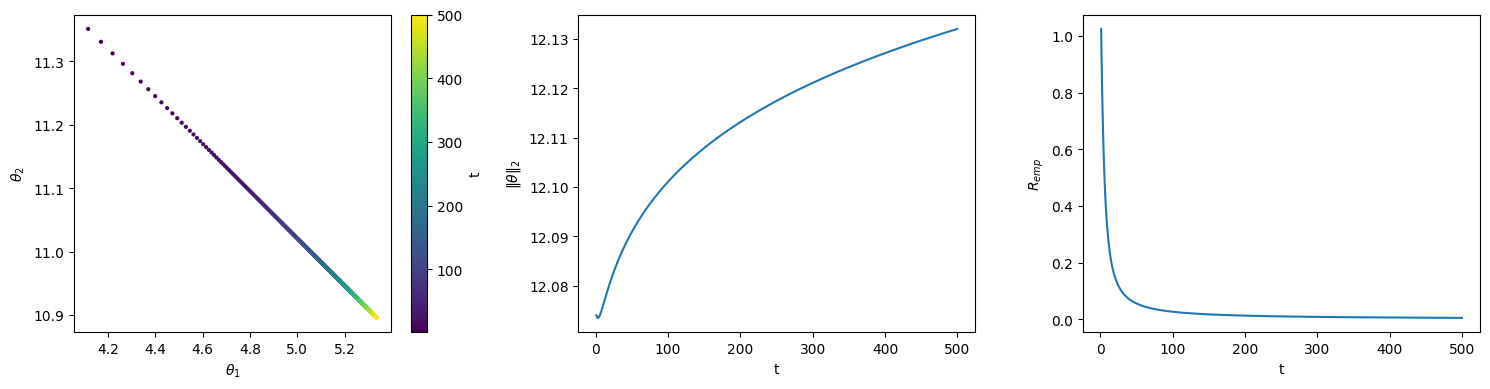

vanilla a=0.02         final theta = ( 5.3362, 10.8954), ||theta|| =  12.132, R_emp = 0.005


In [3]:
#| label: solution_d_code
def grad(theta, lam):
    """Gradient of the L2-regularized logistic risk (note 2*lam*theta)."""
    theta = np.asarray(theta, dtype=float)
    sigma = 1 / (1 + np.exp(-(X @ theta)))
    return 2 * lam * theta + (sigma - y) @ X


def gd_step(theta, alpha, lam):
    return theta - alpha * grad(theta, lam)


def plot_fun(step_fn, lam, n_iters=500, theta0=np.zeros(2), label=""):
    """Run GD for n_iters; plot trace, ||theta||, R_emp; print final state."""
    theta = theta0.copy()
    thetas = np.empty((n_iters, 2))
    norms = np.empty(n_iters)
    fs = np.empty(n_iters)
    for i in range(n_iters):
        theta = step_fn(theta)
        thetas[i] = theta
        norms[i] = np.linalg.norm(theta)
        fs[i] = f(theta, lam)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sc = axes[0].scatter(thetas[:, 0], thetas[:, 1],
                         c=np.arange(1, n_iters + 1), s=4, cmap="viridis")
    axes[0].set_xlabel(r"$\theta_1$"); axes[0].set_ylabel(r"$\theta_2$")
    fig.colorbar(sc, ax=axes[0], label="t")
    axes[1].plot(np.arange(1, n_iters + 1), norms)
    axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$\|\theta\|_2$")
    axes[2].plot(np.arange(1, n_iters + 1), fs)
    axes[2].set_xlabel("t"); axes[2].set_ylabel(r"$R_{emp}$")
    plt.tight_layout()
    plt.show()

    print(f"{label:22} final theta = ({theta[0]:7.4f}, {theta[1]:7.4f}), "
          f"||theta|| = {norms[-1]:7.3f}, R_emp = {fs[-1]:.3f}")


## alpha = 0.01, lambda = 0 (vanilla GD, unregularized)
plot_fun(lambda theta: gd_step(theta, 0.01, 0), lam=0, label="vanilla a=0.01")
## alpha = 0.02, lambda = 0
plot_fun(lambda theta: gd_step(theta, 0.02, 0), lam=0, label="vanilla a=0.02")

**Observation.** Both step sizes drive the iterates outward indefinitely while the loss falls monotonically toward zero. The $\|\bm{\theta}\|$ curves show a *steep early climb* followed by progressively slower growth. The iterates never plateau; they just creep outward more slowly as $t$ grows.

The two step sizes differ mainly in the **terminal norm**: at iteration 500, $\|\bm{\theta}\|$ at $\alpha = 0.02$ is roughly twice that at $\alpha = 0.01$ — the per-iteration motion scales with $\alpha$, accumulated over a fixed number of steps.

Theoretically GD does not converge here because $\mathcal{R}_\text{emp}$ has no minimum (a). Empirically: the $\|\bm{\theta}\|$ curve never plateaus, even when its rate of growth becomes very slow.

## (e) Add L2 regularization

Repeat (d), but minimize $\lambda\|\bm{\theta}\|^2 + \mathcal{R}_\text{emp}(\bm{\theta})$ with $\lambda = 1$. What changes?

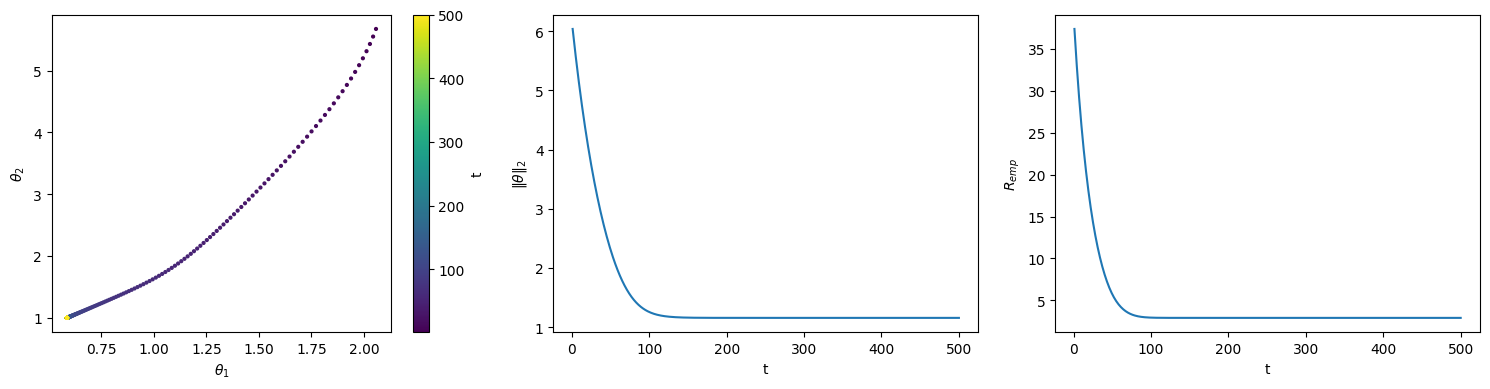

reg a=0.01             final theta = ( 0.5860,  0.9966), ||theta|| =   1.156, R_emp = 2.907


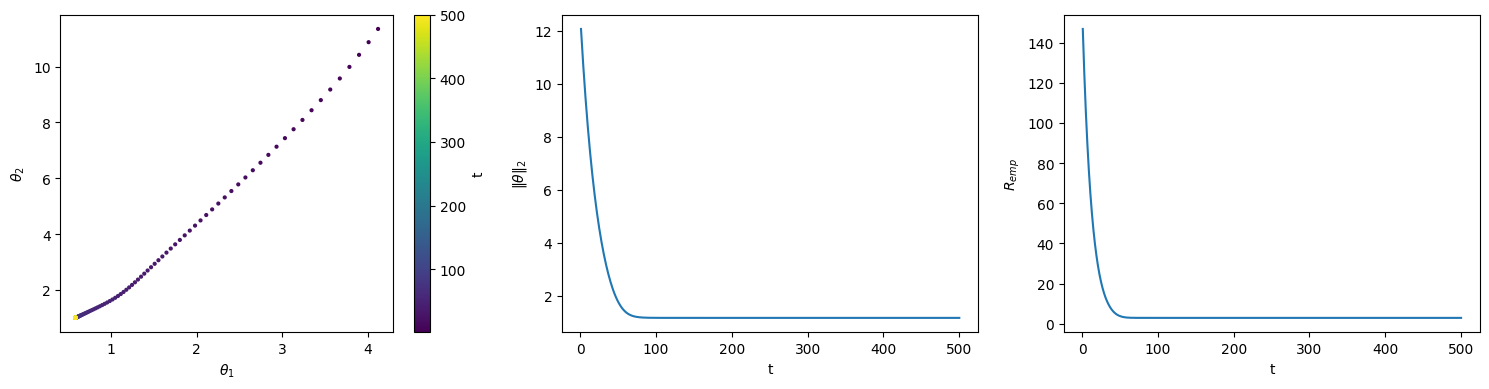

reg a=0.02             final theta = ( 0.5860,  0.9966), ||theta|| =   1.156, R_emp = 2.907


In [4]:
#| label: solution_e_code
## lambda = 1, alpha = 0.01
plot_fun(lambda theta: gd_step(theta, 0.01, 1), lam=1, label="reg a=0.01    ")
## lambda = 1, alpha = 0.02
plot_fun(lambda theta: gd_step(theta, 0.02, 1), lam=1, label="reg a=0.02    ")

**What changes.** The regularizer $\lambda\|\bm{\theta}\|^2$ gives the objective a finite minimum. Instead of the iterates growing without bound as in (d), the $\|\bm{\theta}\|$ curves now rise and then settle to a plateau — the signature of convergence — and both step sizes converge to the same minimum.

## (f) Visualize the regularized empirical risk

Visualize the regularized empirical risk $\lambda\|\bm{\theta}\|^2 + \mathcal{R}_\text{emp}(\bm{\theta})$ on $[-1, 4] \times [-1, 4]$ with $\lambda = 1$.

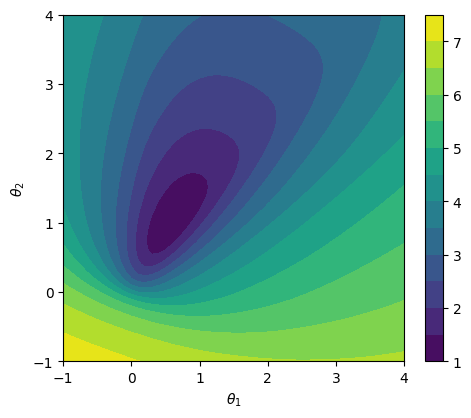

In [5]:
#| label: solution_f_code
Z_reg = np.array([[np.log(f(np.array([t1, t2]), 1)) for t1 in grid]
                  for t2 in grid])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cs = ax.contourf(T1, T2, Z_reg, levels=14)
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")
fig.colorbar(cs)
plt.show()

Compare to (b): the regularized landscape has closed level sets around a finite minimum — a **bowl**, not a slide. This is what makes GD converge in (e). The minimum's location is biased toward the origin compared to the unregularized maximum-likelihood direction, by an amount depending on $\lambda$.

## (g) Gradient descent with backtracking line search

Repeat (e) but with **backtracking line search**: at each step, propose $\bm{\theta}_{\text{prop}} = \bm{\theta} - \alpha \nabla f(\bm{\theta})$ and accept it if it satisfies the Armijo condition

$$f(\bm{\theta}_{\text{prop}}) \leq f(\bm{\theta}) - \gamma\, \alpha\, \|\nabla f(\bm{\theta})\|^2,$$

otherwise shrink $\alpha \leftarrow \tau \alpha$ and try again. Use $\gamma = 0.9$, $\tau = 0.5$.

*Note:* the trace below visualizes from iteration $t = 1$ (after one backtracking step), not from the starting point $\bm{\theta}^{[0]} = (0, 0)^\top$.

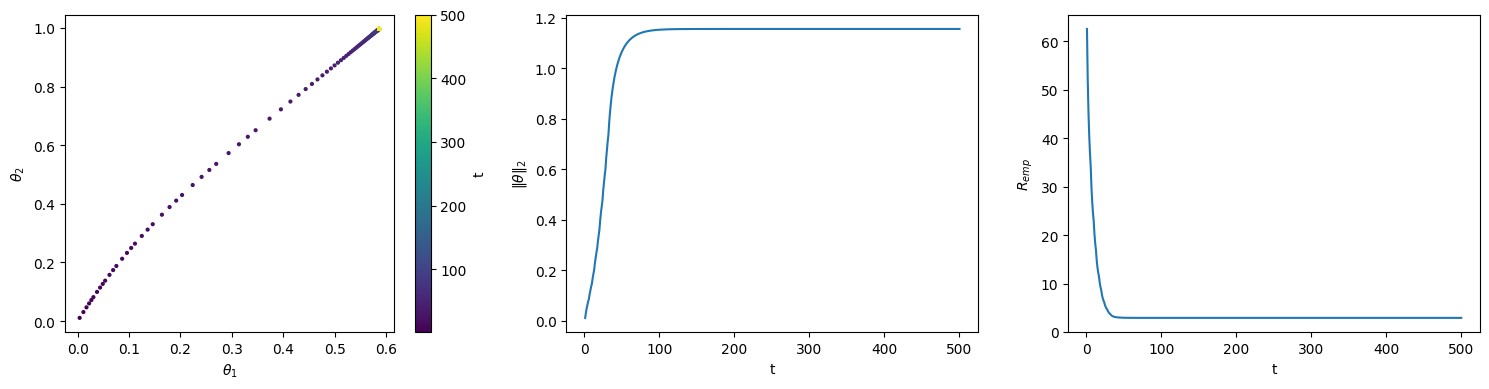

backtrack a=0.01       final theta = ( 0.5860,  0.9966), ||theta|| =   1.156, R_emp = 2.907


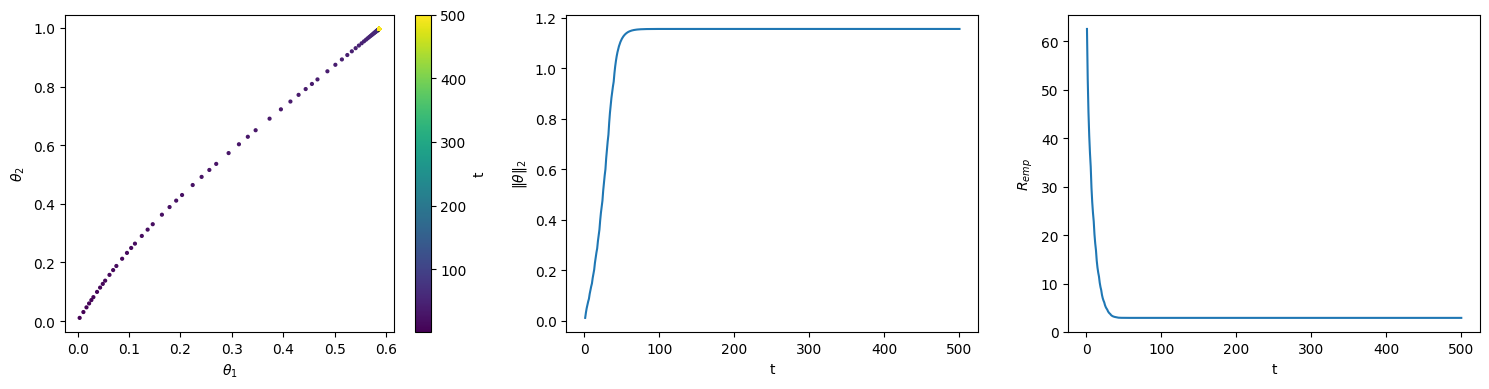

backtrack a=0.02       final theta = ( 0.5860,  0.9966), ||theta|| =   1.156, R_emp = 2.907


In [6]:
#| label: solution_g_code
def gd_backtracking_step(theta, alpha, gamma, tau, lam, max_iter=1000):
    """Single GD step with Armijo backtracking. Shrinks alpha until accepted."""
    f_theta = f(theta, lam)
    d_theta = grad(theta, lam)
    grad_sq = d_theta @ d_theta
    for _ in range(max_iter):
        theta_prop = theta - alpha * d_theta
        if f(theta_prop, lam) <= f_theta - gamma * alpha * grad_sq:
            return theta_prop
        alpha *= tau
    raise RuntimeError(
        f"backtracking failed to find a descent step after {max_iter} shrinks; "
        f"check curvature / starting point / gamma={gamma}")


## lambda = 1, alpha_init = 0.01
plot_fun(
    lambda theta: gd_backtracking_step(theta, 0.01, 0.9, 0.5, 1),
    lam=1, label="backtrack a=0.01")
## lambda = 1, alpha_init = 0.02
plot_fun(
    lambda theta: gd_backtracking_step(theta, 0.02, 0.9, 0.5, 1),
    lam=1, label="backtrack a=0.02")

**Observation.** Backtracking adapts $\alpha$ per iteration: the step is automatically shortened when a proposed update would not produce a sufficient decrease. The loss curve is monotone non-increasing by construction (Armijo condition), and both initial $\alpha$ values converge to the same minimum found in (e).

**Where this leaves us.** This exercise traces a ladder of fixes:

- Vanilla GD on separable data → diverges (a, d).
- L2 regularization → finite minimum (e).
- Backtracking → adaptive step that does not depend on the user picking the right $\alpha$ up front (g).

The next stage is **direction**: even with a well-chosen step, the local-gradient direction is suboptimal on poorly-conditioned problems — when the level sets are elongated, the negative gradient points mostly across the valley rather than along it, so the iterates zig-zag and progress slowly. Exercise 7 introduces *momentum* to break that limitation.